In [2]:
from functools import partial
from typing import Union

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  
from jax.tree import map as tree_map
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

import os
import sys
relative_path = os.path.join('..', '..')  # Go up two levels to reach precond-gd
sys.path.append(os.path.abspath(relative_path))


from run_pinns import *

# from precond_gd.utils.cg import conjugate_gradient
# from precond_gd.utils import datasets
# from precond_gd.models.MLP import MLP_1D
# from precond_gd.data.data_utils import batch_data_pinns, generate_training_data
# from precond_gd.utils.jacobian_tools import flatten_jacobian
# from precond_gd.utils.model_utils import create_train_state
# from precond_gd.utils.plotting import plot_results

from load_metrics import load_metrics

In [3]:
def plot_loss_and_error(history_groups, colors, error_every=100, max_valid_steps=500, ylim=None):
    """
    Plot training loss and L2 error side-by-side for multiple solver groups.

    Args:
        history_groups: list of (history_dict, linestyle, alpha)
        colors: function taking int -> color
        error_every: frequency of l2_error recording (default every 100 epochs)
        max_valid_steps: max steps to plot if NaNs are detected
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey="row")
    ax_loss, ax_error, ax_error_pde, ax_error_bc = axes

    color_offset = 0

    for group_idx, (history_dict, linestyle, alpha) in enumerate(history_groups):
        for i, (slvr, metrics) in enumerate(history_dict.items()):
            #idx = color_offset + i
            idx = i

            # --- Loss ---
            loss_arr = np.array(metrics['train_loss'])

            nan = ''
            if np.isnan(np.min(loss_arr)):
                loss_arr = loss_arr[:max_valid_steps]
                nan = '(NaNs)'
                
            ax_loss.semilogy(
                loss_arr,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- Total Error ---
            errors = np.array(metrics.get('l2_error', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- PDE Error ---
            errors = np.array(metrics.get('l2_error_pde', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error_pde.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

            # --- BC Error ---
            errors = np.array(metrics.get('l2_error_bc', []))
            nan = ''
            if np.isnan(np.min(errors)):
                errors = errors[:max_valid_steps // error_every]
                nan = '(NaNs)'
                
            x_vals = np.arange(0, len(errors)) * error_every
            ax_error_bc.semilogy(
                x_vals, errors,
                label=f"{slvr}{nan}",
                linestyle=linestyle,
                color=colors(idx),
                alpha=alpha
            )

        color_offset += len(history_dict)

    ax_loss.set_title('Training Loss')
    ax_error.set_title('L2 Error')
    ax_error_pde.set_title('L2 Error (PDE)')
    ax_error_bc.set_title('L2 Error (BC)')

    
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.grid()

        if ylim:
            ax.set_ylim(ylim)
    
    ax.legend()

    plt.tight_layout()
    plt.show()


In [4]:
num_interior = 80 * 8
num_boundary = 20 * 2
interior_points, boundary_points = generate_training_data(num_interior, num_boundary)

dims = 256


NM = ((1,1), 
      #(1,2), (2,1), # sanity check
      (2,2), (3,3), #(4,4)
     )

problem_data = (interior_points, boundary_points)

# def get_forcing_fxn(n, m):
#     return lambda x: (n**2 + m**2) * (jnp.pi**2) * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(m * jnp.pi * x[1])


def get_forcing_fxn(n, m):
    return lambda x: (n**2 + m**2) * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(m * jnp.pi * x[1])

def get_solution_fxn(n, m):
    return lambda x: (1.0 / (jnp.pi**2)) * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(m * jnp.pi * x[1])



path = "./data_new"
n_curves = len(NM)
colors = plt.cm.get_cmap('tab10', n_curves)

/tmp/ipykernel_57884/3841752532.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_curves)


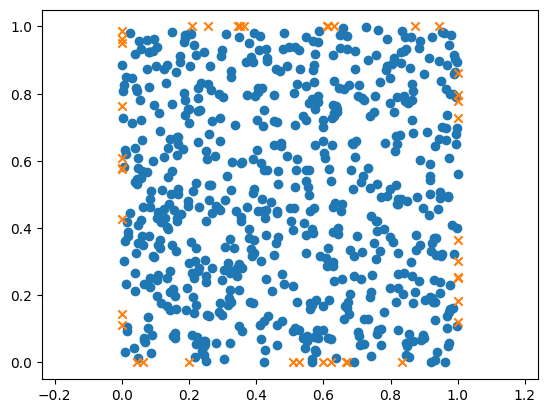

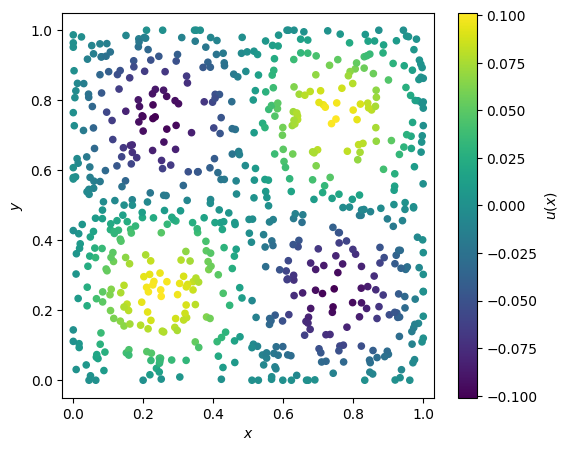

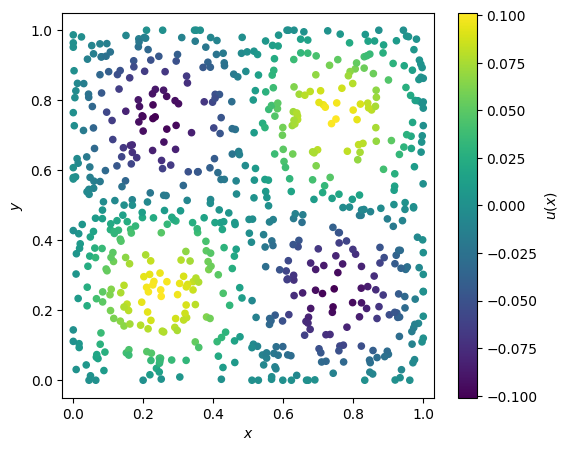

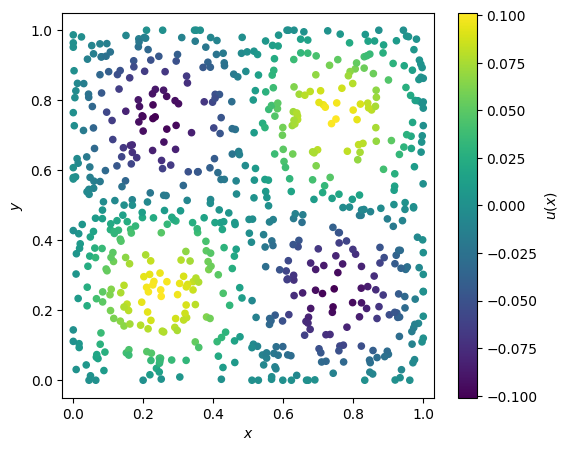

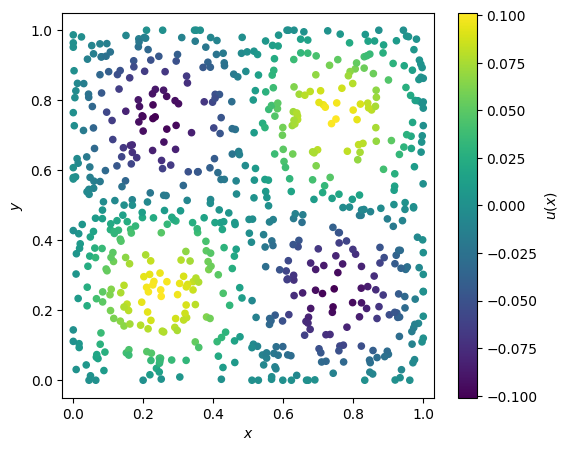

In [5]:
plt.scatter(interior_points[:,0], interior_points[:,1], marker='o')
plt.scatter(boundary_points[:,0], boundary_points[:,1], marker='x')
plt.axis('equal')
plt.show()

for n,m in [(1,1), (1, 2), (2,2), (3,3)]:

    u_pde = get_solution_fxn(2,2)(interior_points.T).squeeze()
    u_bc = get_solution_fxn(2,2)(boundary_points.T).squeeze()
    
    b_bc = get_forcing_fxn(2,2)(boundary_points.T).squeeze()
    
    assert jnp.allclose(u_bc, jnp.zeros_like(u_bc))
    assert jnp.allclose(b_bc, jnp.zeros_like(b_bc))
    
    # Stack points and solution values
    all_points = jnp.vstack([interior_points, boundary_points])
    all_u = jnp.concatenate([u_pde, u_bc])
    
    # Plot
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(all_points[:, 0], all_points[:, 1], c=all_u, cmap='viridis', s=20)
    plt.colorbar(sc, label='$u(x)$')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.axis('equal')
    plt.show()


In [21]:
num_runs = 5

# SGD

In [22]:

metrics_history_sgd = {}

for n,m in NM:
    for k in range(num_runs):
        name = f"{path}/sgd2_fx_{n}_fy_{m}_seed_{k}"    
        try:
            metrics_history_sgd[name] = load_metrics(f"{name}.pkl")
        
        except:
            model = MLP_1D(1, dims)
            state = create_train_state(model, rng=jax.random.key(k), learning_rate=1e-3, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
            state, metrics = train_model(state,
                                         problem_data=problem_data,
                                         forcing_function=get_forcing_fxn(n, m),
                                         solution_function=get_solution_fxn(n, m),
                                         num_iterations=10000,
                                         lm_schedule=None,
                                         batch_size=200,
                                         metrics_file=name
                                         )
            
            metrics_history_sgd[name] = metrics


  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)


100%|███████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:36<00:00, 103.67it/s, loss=1.2471e-02]



Training complete. Saving metrics to ./data_new/sgd2_fx_1_fy_1_seed_0.pkl...
Metrics saved successfully.


  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

...


Training complete. Saving metrics to ./data_new/sgd2_fx_3_fy_3_seed_3.pkl...
Metrics saved successfully.


  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)


100%|███████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:27<00:00, 114.81it/s, loss=1.3628e+00]



Training complete. Saving metrics to ./data_new/sgd2_fx_3_fy_3_seed_4.pkl...
Metrics saved successfully.


In [23]:

metrics_history_adam = {}

for n,m in NM:
    for k in range(num_runs):

        name = f"{path}/adam2_fx_{n}_fy_{m}_seed_{k}"    
        try:
            metrics_history_adam[name] = load_metrics(f"{name}.pkl")
        
        except:
            model = MLP_1D(1, dims)
            state = create_train_state(model,rng=jax.random.key(k), learning_rate=1e-2, momentum=0, optimizer='adam', shape=jnp.ones((1, 2)))
            state, metrics = train_model(state,
                                         problem_data=problem_data,
                                         forcing_function=get_forcing_fxn(n, m),
                                         solution_function=get_solution_fxn(n, m),
                                         num_iterations=10000,
                                         lm_schedule=None,
                                         batch_size=200,
                                         metrics_file=name
                                         )
            
            metrics_history_adam[name] = metrics


  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)


100%|███████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:29<00:00, 111.85it/s, loss=7.5218e-06]



Training complete. Saving metrics to ./data_new/adam2_fx_1_fy_1_seed_0.pkl...
Metrics saved successfully.


  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

...


Training complete. Saving metrics to ./data_new/adam2_fx_3_fy_3_seed_3.pkl...
Metrics saved successfully.


  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)


100%|███████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:34<00:00, 106.03it/s, loss=1.8011e-02]



Training complete. Saving metrics to ./data_new/adam2_fx_3_fy_3_seed_4.pkl...
Metrics saved successfully.


# SMW

In [24]:
metrics_history_smw_lamb_1e1 = {}

lr = 1e-1
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
)

for n,m in NM:
    for k in range(num_runs):
        name = f"{path}/smw2_fx_{n}_fy_{m}_seed_{k}"
        
        try:
            metrics_history_smw_lamb_1e1[name] = load_metrics(f"{name}.pkl")
        
        except:
            model = MLP_1D(1, dims)
            state = create_train_state(model,rng=jax.random.key(k), learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
            state, metrics = train_model(state,
                                         problem_data=problem_data,
                                         forcing_function=get_forcing_fxn(n, m),
                                         solution_function=get_solution_fxn(n, m),
                                         num_iterations=10000,
                                         lm_schedule=lm_info,
                                         batch_size=200,
                                         metrics_file=name,
                                         )
        
        
            metrics_history_smw_lamb_1e1[name] = metrics

  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)
Running smw


100%|████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:02<00:00, 81.48it/s, loss=1.2263e-05]



Training complete. Saving metrics to ./data_new/smw2_fx_1_fy_1_seed_0.pkl...
Metrics saved successfully.


  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

...


Training complete. Saving metrics to ./data_new/smw2_fx_3_fy_3_seed_3.pkl...
Metrics saved successfully.


  0%|                                                                                                             | 0/10000 [00:00<?, ?it/s]

(188, 2) (12, 2)
Running smw


100%|████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:01<00:00, 82.24it/s, loss=6.5461e-04]



Training complete. Saving metrics to ./data_new/smw2_fx_3_fy_3_seed_4.pkl...
Metrics saved successfully.


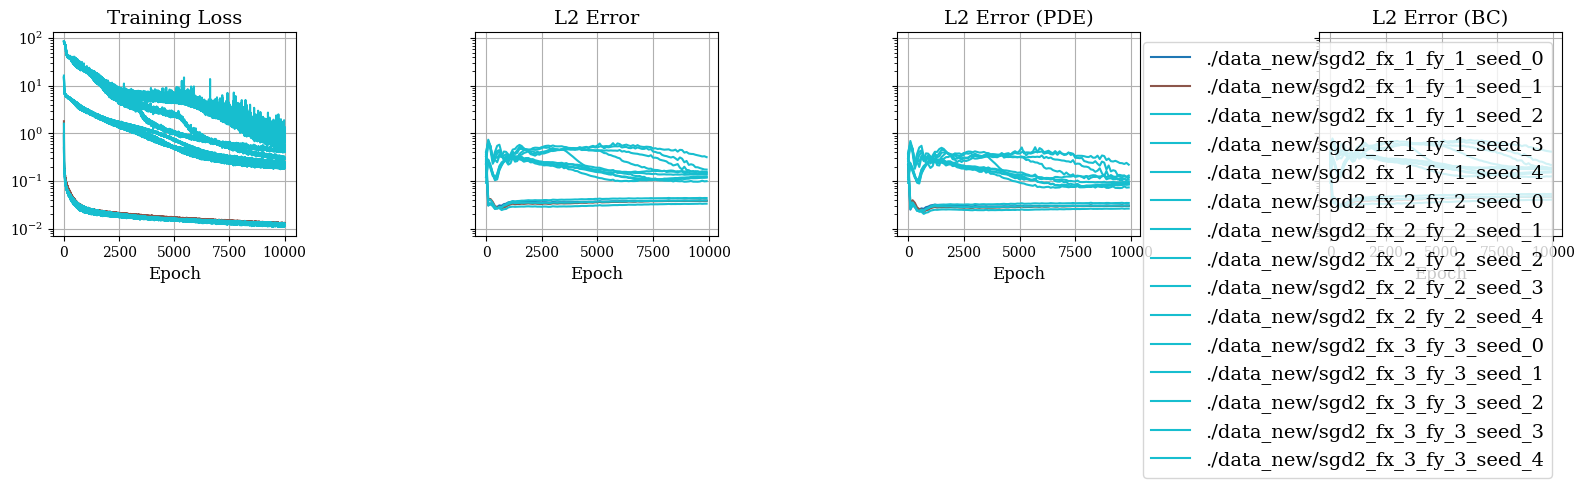

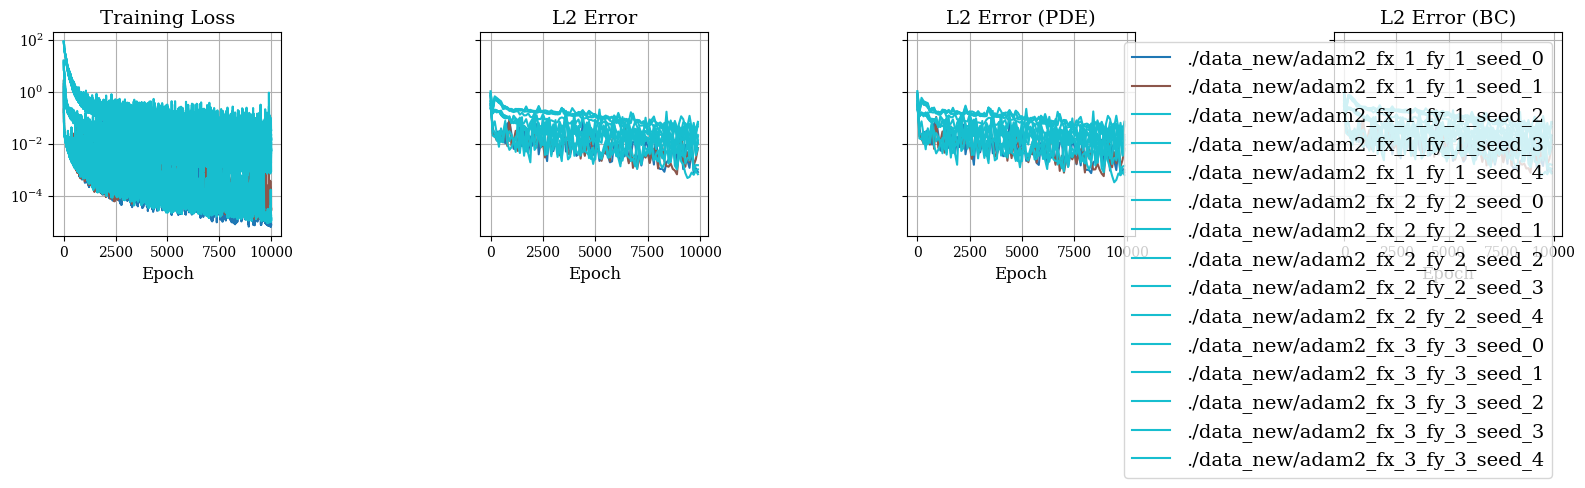

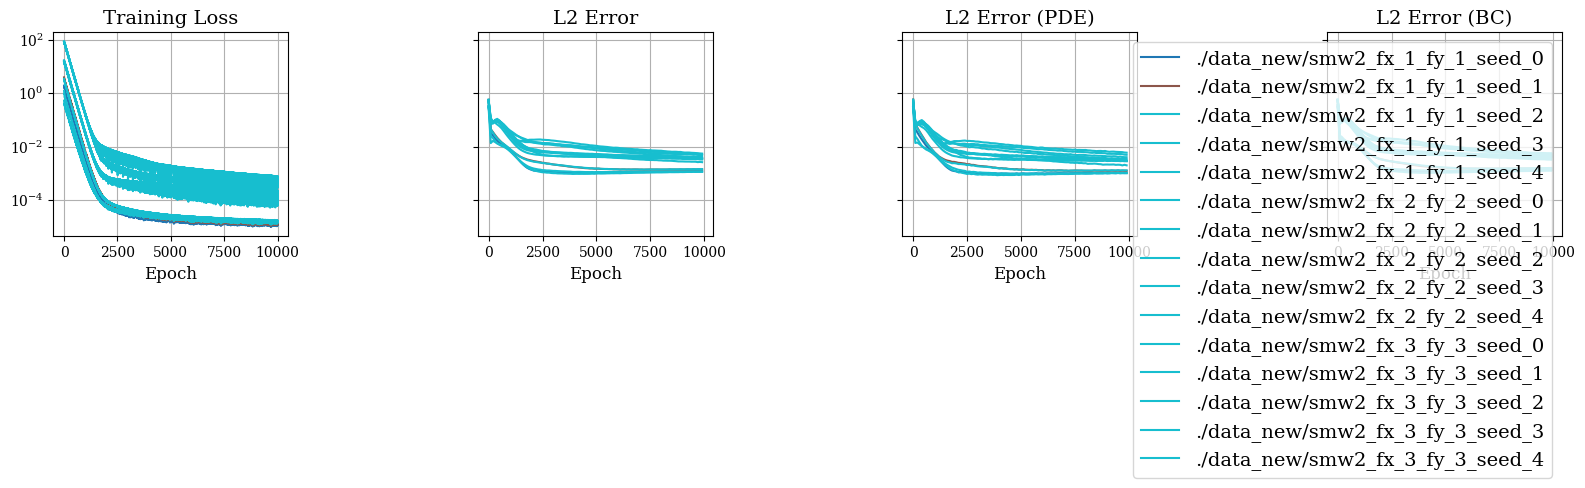

In [25]:
#########################################
# SGD
plot_specs = [
    (metrics_history_sgd, 'solid', 1.),
]
plot_loss_and_error(plot_specs, colors)

#########################################
# Adam
plot_specs = [
    (metrics_history_adam, 'solid', 1.),
]
plot_loss_and_error(plot_specs, colors)

#########################################
# SMW
plot_specs = [
    (metrics_history_smw_lamb_1e1, 'solid', 1.),
]
plot_loss_and_error(plot_specs, colors)

/tmp/ipykernel_57884/3141815510.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


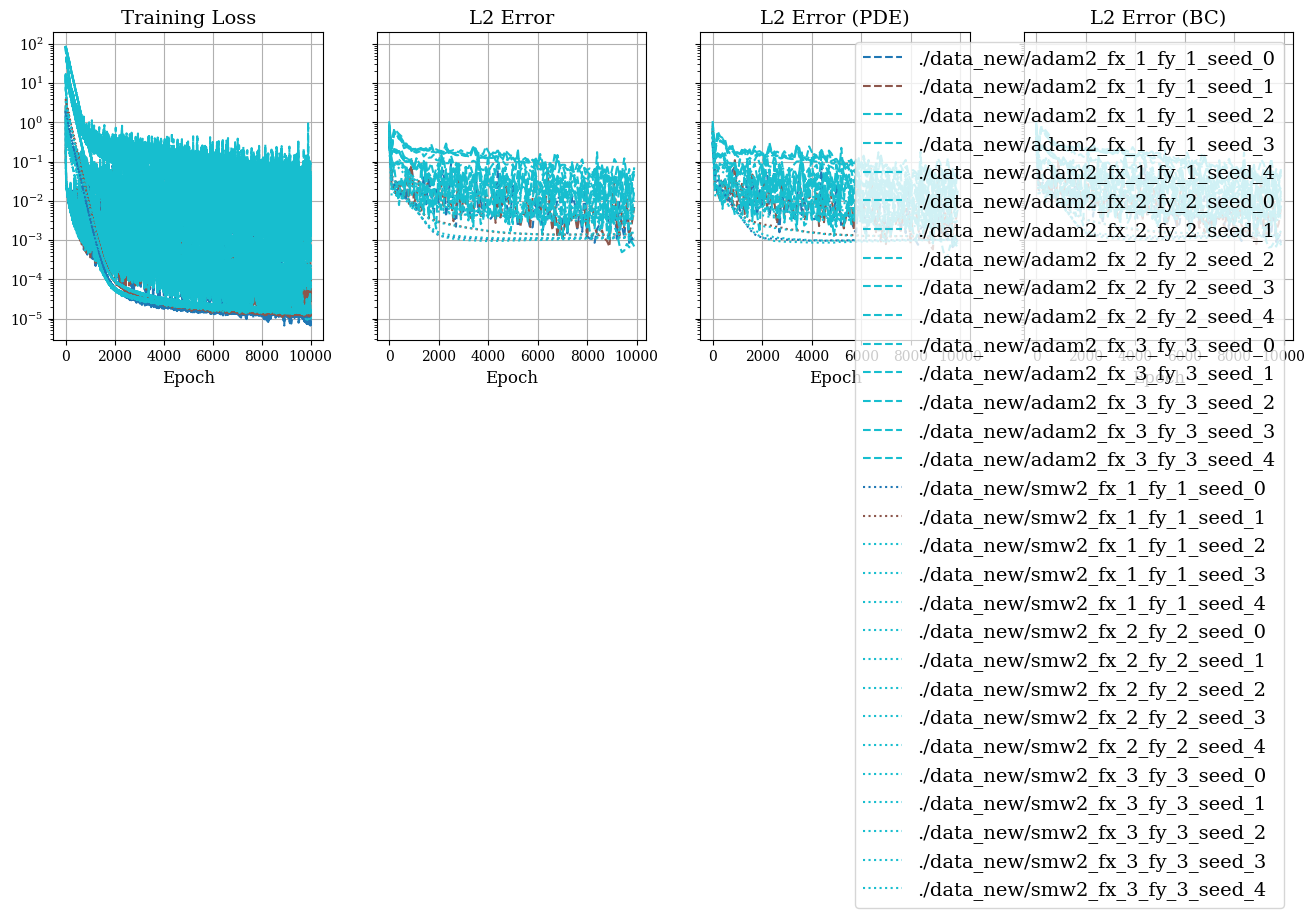

In [26]:

plot_specs = [
    #(metrics_history_sgd, 'solid', 1.),
    (metrics_history_adam, 'dashed', 1.),
    (metrics_history_smw_lamb_1e1, 'dotted', 1.),
]
plot_loss_and_error(plot_specs, colors)


<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_57884/589942728.py:52: SyntaxWarning: invalid escape sequence '\m'
  subfigs[i].set_title(f'LM $\mu=0.1$')


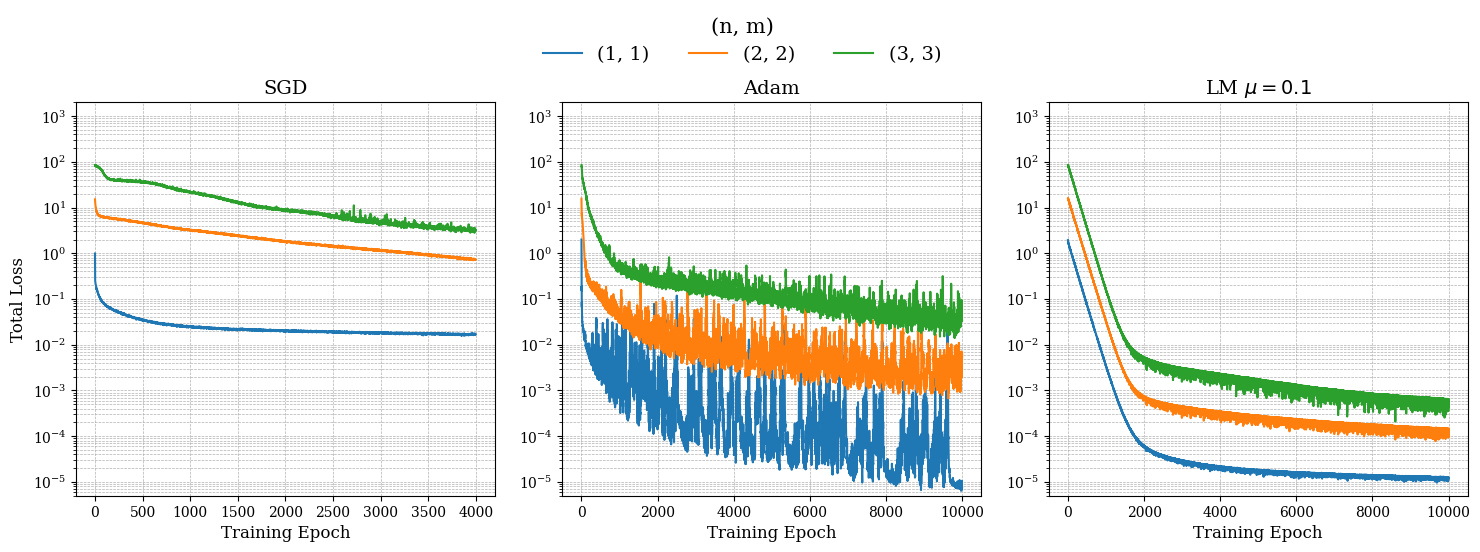

In [27]:
# Create subfigures

import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,            # base font size
    'font.family': 'serif',     # font family: 'serif', 'sans-serif', 'monospace', etc.
    'axes.titlesize': 14,       # subplot titles
    'axes.labelsize': 12,       # axis labels
    'xtick.labelsize': 10,      # x tick labels
    'ytick.labelsize': 10,      # y tick labels
    'legend.fontsize': 14,      # legend font
    'legend.title_fontsize': 15 # legend title
})


nplot = 3

fig, subfigs = plt.subplots(1, nplot, figsize=(5*nplot, 5))  # 1 row


i = 0
subfigs[i].set_title(f'SGD')

metrics_history_sgd_11 = metrics_history_sgd[path+'/sgd2_fx_1_fy_1_seed_0']
metrics_history_sgd_22 = metrics_history_sgd[path+'/sgd2_fx_2_fy_2_seed_0']
metrics_history_sgd_33 = metrics_history_sgd[path+'/sgd2_fx_3_fy_3_seed_0']

subfigs[i].semilogy(metrics_history_sgd_11['train_loss'][0:4000], alpha=1)  # Use alpha for transparency
subfigs[i].semilogy(metrics_history_sgd_22['train_loss'][0:4000], alpha=1)  # Use alpha for transparency
subfigs[i].semilogy(metrics_history_sgd_33['train_loss'][0:4000], alpha=1)  # Use alpha for transparency


i = 1
subfigs[i].set_title(f'Adam')

metrics_history_adam_11 = metrics_history_adam[path+'/adam2_fx_1_fy_1_seed_0']
metrics_history_adam_22 = metrics_history_adam[path+'/adam2_fx_2_fy_2_seed_0']
metrics_history_adam_33 = metrics_history_adam[path+'/adam2_fx_3_fy_3_seed_0']

subfigs[i].semilogy(metrics_history_adam_11['train_loss'], alpha=1)  # Use alpha for transparency
subfigs[i].semilogy(metrics_history_adam_22['train_loss'], alpha=1)  # Use alpha for transparency
subfigs[i].semilogy(metrics_history_adam_33['train_loss'], alpha=1)  # Use alpha for transparency

i = 2
subfigs[i].set_title(f'LM $\mu=0.1$')

metrics_history_smw_11 = metrics_history_smw_lamb_1e1[path+'/smw2_fx_1_fy_1_seed_0']
metrics_history_smw_22 = metrics_history_smw_lamb_1e1[path+'/smw2_fx_2_fy_2_seed_0']
metrics_history_smw_33 = metrics_history_smw_lamb_1e1[path+'/smw2_fx_3_fy_3_seed_0']

subfigs[i].semilogy(metrics_history_smw_11['train_loss'], alpha=1)  # Use alpha for transparency
subfigs[i].semilogy(metrics_history_smw_22['train_loss'], alpha=1)  # Use alpha for transparency
subfigs[i].semilogy(metrics_history_smw_33['train_loss'], alpha=1)  # Use alpha for transparency




for s in subfigs:
    
    s.grid(True, which='both', linestyle='--', linewidth=0.5)
    s.set_ylim(5e-6, 2e3)
    s.set_xlabel("Training Epoch")


subfigs[0].set_ylabel("Total Loss")


# Shared legend above all subplots
legend = fig.legend(['(1, 1)', '(2, 2)', '(3, 3)'],
           title='(n, m)', loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.12), frameon=False)

plt.tight_layout()
plt.savefig('pinns.png', bbox_extra_artists=(legend,), bbox_inches='tight')
plt.show()

<>:68: SyntaxWarning: invalid escape sequence '\m'
<>:68: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_57884/2765710559.py:68: SyntaxWarning: invalid escape sequence '\m'
  subfigs[i].set_title(f'LM $\mu=0.1$')


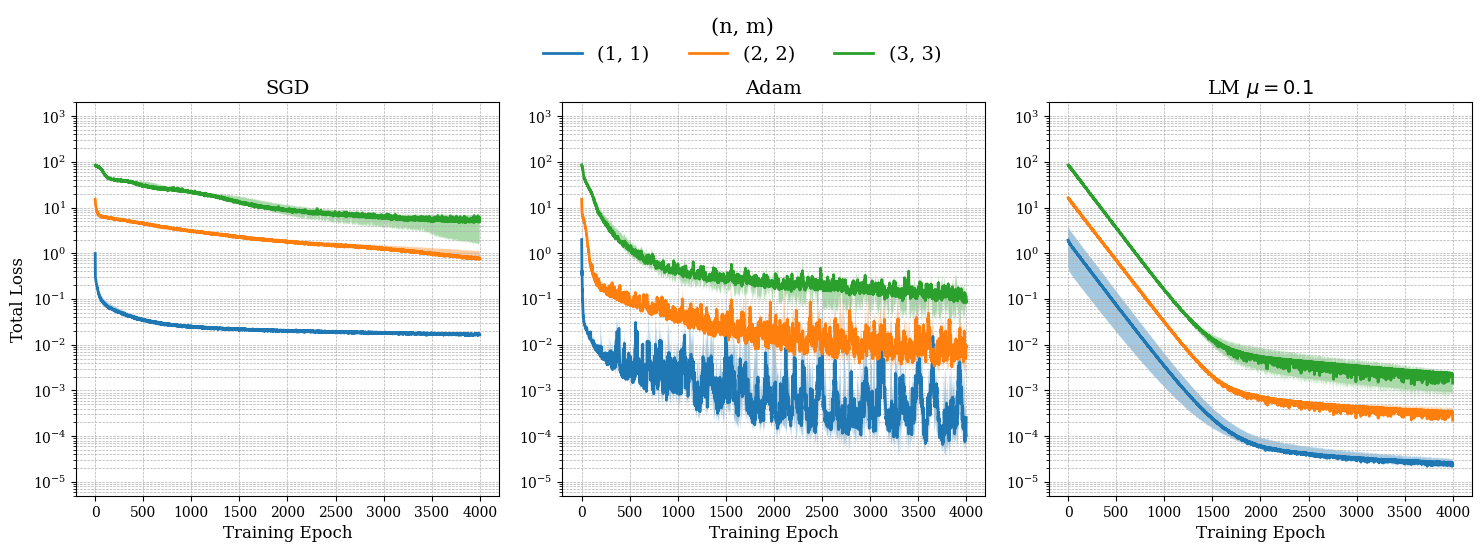

In [38]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,            # base font size
    'font.family': 'serif',     # font family: 'serif', 'sans-serif', etc.
    'axes.titlesize': 14,       # subplot titles
    'axes.labelsize': 12,       # axis labels
    'xtick.labelsize': 10,      # x tick labels
    'ytick.labelsize': 10,      # y tick labels
    'legend.fontsize': 14,      # legend font
    'legend.title_fontsize': 15 # legend title
})

nplot = 3
fig, subfigs = plt.subplots(1, nplot, figsize=(5 * nplot, 5))  # 1 row

# Helper function to compute statistics and plot
def plot_with_statistics(ax, metrics_history, path_prefix, fx_fy_pairs, label_prefix):
    for fx, fy in fx_fy_pairs:
        # Collect losses across seeds
        losses = []
        for seed in range(5):  # Assuming 5 seeds
            key = f"{path_prefix}_fx_{fx}_fy_{fy}_seed_{seed}"
            losses.append(metrics_history[key]['train_loss'][0:4000])  # Truncate to 4000 epochs
        
        # Convert to numpy array for easier computation
        losses_array = np.array(losses)  # Shape: (num_seeds, num_epochs)
        
        # Compute statistics
        median_loss = np.median(losses_array, axis=0)
        min_loss = np.min(losses_array, axis=0)
        max_loss = np.max(losses_array, axis=0)
        
        # Plot median line with label
        if label_prefix == 'LM':
            ax.semilogy(median_loss, label=f"({fx}, {fy})", linewidth=2.0)
        else: 
            ax.semilogy(median_loss, linewidth=2.0)
        
        # Fill between min and max (no label for the shaded area)
        ax.fill_between(range(len(median_loss)), min_loss, max_loss, alpha=0.4)

# SGD subplot
i = 0
subfigs[i].set_title(f'SGD')
plot_with_statistics(
    subfigs[i],
    metrics_history_sgd,
    path + '/sgd2',
    [(1, 1), (2, 2), (3, 3)],
    'SGD'
)

# Adam subplot
i = 1
subfigs[i].set_title(f'Adam')
plot_with_statistics(
    subfigs[i],
    metrics_history_adam,
    path + '/adam2',
    [(1, 1), (2, 2), (3, 3)],
    'Adam'
)

# LM subplot
i = 2
subfigs[i].set_title(f'LM $\mu=0.1$')
plot_with_statistics(
    subfigs[i],
    metrics_history_smw_lamb_1e1,
    path + '/smw2',
    [(1, 1), (2, 2), (3, 3)],
    'LM'
)

# Add grid, axis limits, and labels
for s in subfigs:
    s.grid(True, which='both', linestyle='--', linewidth=0.5)
    s.set_ylim(5e-6, 2e3)
    s.set_xlabel("Training Epoch")

subfigs[0].set_ylabel("Total Loss")

# Shared legend above all subplots
legend = fig.legend(title='(n, m)',
                    
    loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.12), frameon=False
)
# legend = fig.legend(['(1, 1)', '(2, 2)', '(3, 3)'],
#            title='(n, m)', loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.12), frameon=False)

plt.tight_layout()
plt.savefig('pinns-2.pdf', bbox_extra_artists=(legend,), bbox_inches='tight')
plt.show()